In [1]:

import kagglehub
import pandas as  pd  
import os
import matplotlib.pyplot as plt
import numpy as np



/workspaces/Deep-Learning/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [35]:
path = kagglehub.dataset_download("sukhmandeepsinghbrar/daily-delhi-climate")
df = pd.read_csv(os.path.join(path, "DailyDelhiClimate.csv"))
df = df[['date', 'meantemp']]
df.head()

,date,meantemp
0,2013-01-01,10.000000
1,2013-01-02,7.400000
2,2013-01-03,7.166667
3,2013-01-04,8.666667
4,2013-01-05,6.000000


In [36]:
df = df.head(300).iloc[::3]
df.shape

(100, 2)

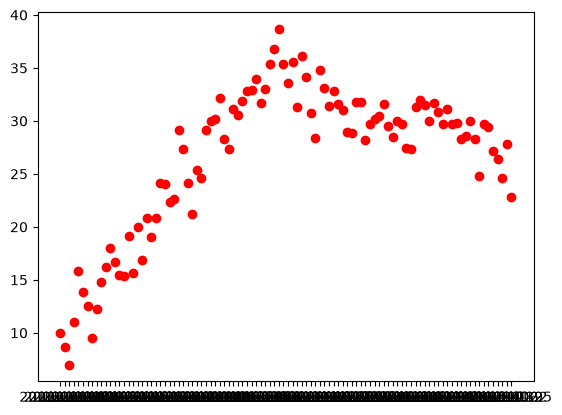

In [37]:
plt.scatter(df['date'], df['meantemp'],color='red')
plt.show()

<h1>Calculating EWMA (Exponentially Weighted Moving Average)</h1>
<br>
Calculating EWMA For various values of alpha i.e. for alpha = 0.9, 0.5, 0.1
EWMA is caluclated by the formula:
<p>S<sub>t</sub> = (1 - &alpha;)S<sub>t-1</sub> + &alpha;X<sub>t</sub> </p>
where
<ul>
    <li>X<sub>t</sub> = current temperature</li>
    <li>S<sub>t</sub> = current EWMA</li>
    <li>S<sub>t-1</sub> = previous EWMA</li>
    <li>&alpha; = smoothing factor</li>
</ul>

The value of α determines how much importance we give to the current observation.<br>
If α is large: The current observation receives more weight. EWMA reacts quickly to recent changes.<br>
If α is small: The previous EWMA receives more weight.EWMA changes slowly and produces a smoother curve.

In [38]:
df = df.reset_index(drop = True)
x=[]
for i in range(9,0,-1):
    df[f'ewma with alpha {i/10}']= df['meantemp'].ewm(alpha=i/10).mean()

#x1 = df['meantemp'].ewm(alpha=0.9).mean()
#df['ewma with alpha 0.9']= x1
#
#x2 = df['meantemp'].ewm(alpha=0.5).mean()
#df['ewma with alpha 0.5']= x2
#
#x3 = df['meantemp'].ewm(alpha=0.1).mean()
#df['ewma with alpha 0.1']= x3


df

,date,meantemp,ewma with alpha 0.9,ewma with alpha 0.8,ewma with alpha 0.7,ewma with alpha 0.6,ewma with alpha 0.5,ewma with alpha 0.4,ewma with alpha 0.3,ewma with alpha 0.2,ewma with alpha 0.1
0,2013-01-01,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000
1,2013-01-04,8.666667,8.787879,8.888889,8.974359,9.047619,9.111111,9.166667,9.215686,9.259259,9.298246
2,2013-01-07,7.000000,7.177177,7.365591,7.553957,7.735043,7.904762,8.061224,8.203957,8.333333,8.450185
3,2013-01-10,11.000000,10.618062,10.277778,9.985886,9.745484,9.555556,9.411765,9.307804,9.236676,9.191625
4,2013-01-13,15.833333,15.311853,14.723645,14.089070,13.435984,12.795699,12.196970,11.660957,11.199032,10.813493
...,...,...,...,...,...,...,...,...,...,...,...
95,2013-10-13,27.166667,27.391194,27.597410,27.770304,27.905497,28.010605,28.109418,28.252616,28.534760,29.147573
96,2013-10-16,26.428571,26.524834,26.662339,26.831091,27.019342,27.219588,27.437080,27.705403,28.113522,28.875663
97,2013-10-19,24.571429,24.766769,24.989611,25.249327,25.550594,25.895508,26.290819,26.765210,27.405104,28.445225
98,2013-10-22,27.800000,27.496677,27.237922,27.034798,26.900238,26.847754,26.894491,27.075647,27.484083,28.380701


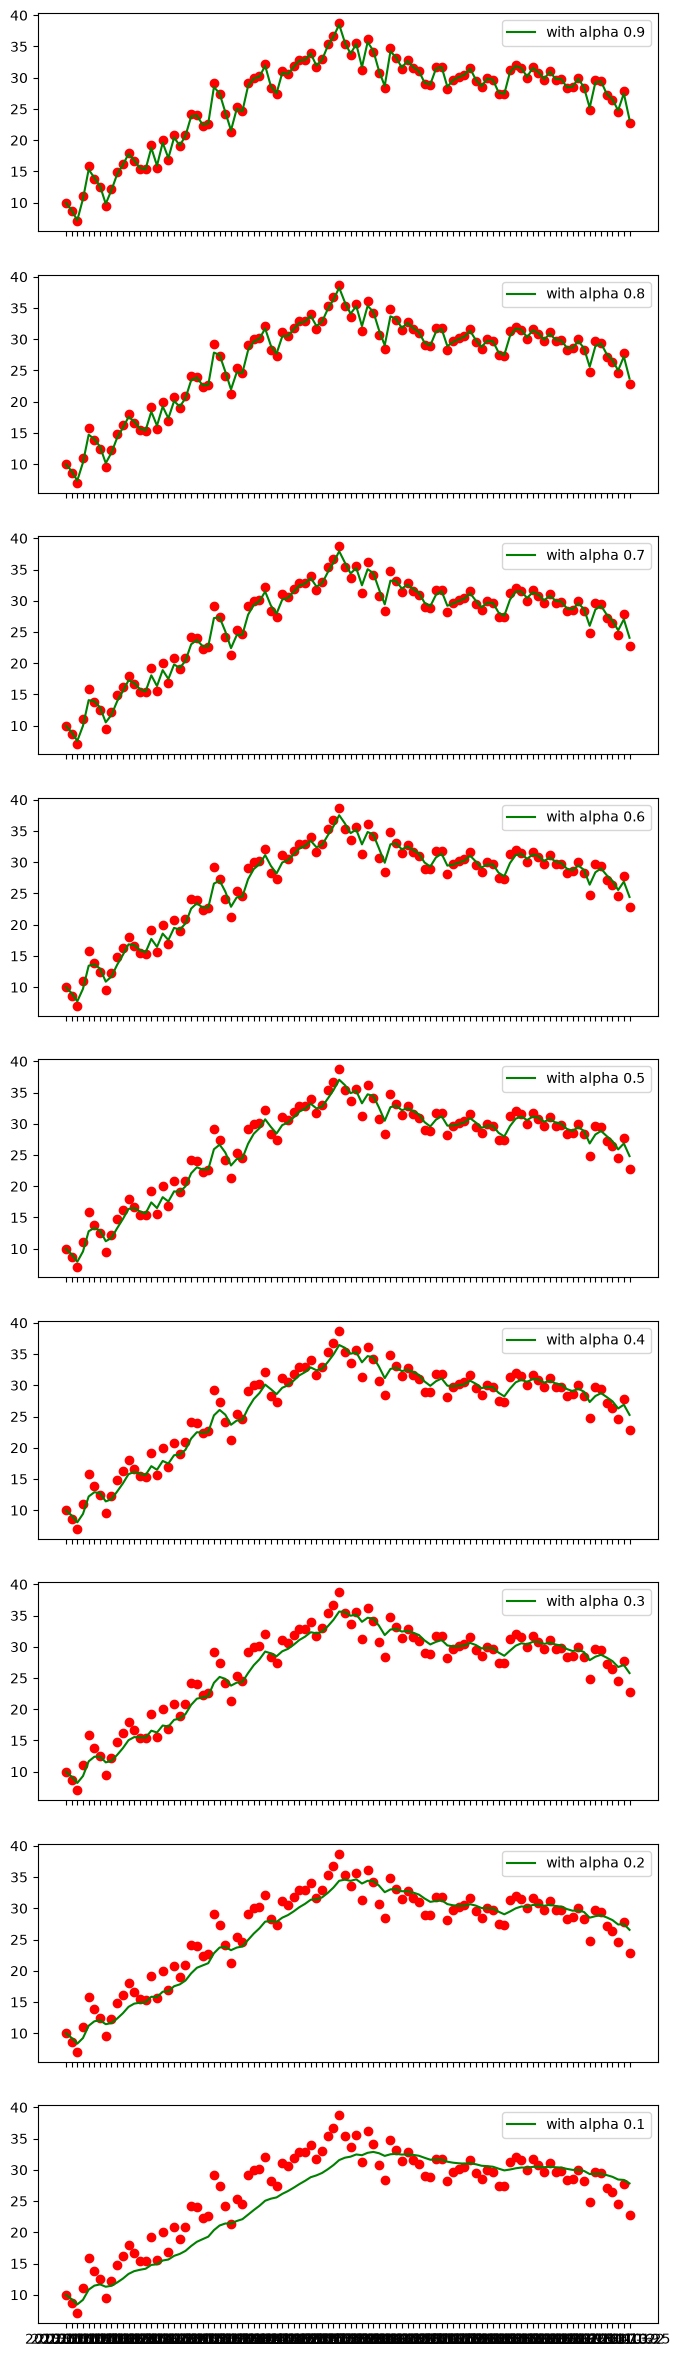

In [53]:
fig, ax = plt.subplots(9, 1, figsize=(8, 30), sharex=True)
for i in range(9,0,-1):
    ax[9-i].scatter(df['date'], df['meantemp'], color = 'red')
    ax[9-i].plot(df['date'],df[f'ewma with alpha {i/10}'], color = 'green', label = f'with alpha {i/10}')
    ax[9-i].legend()

#ax[0].scatter(df['date'], df['meantemp'], color = 'red')
#ax[0].plot(df['date'],x1, color = 'purple', label = 'with alpha 0.9')
#ax[0].legend()
#ax[1].scatter(df['date'], df['meantemp'], color = 'red')
#ax[1].plot(df['date'],x2, color = 'green', label = 'with alpha 0.5')
#ax[1].legend()
#ax[2].scatter(df['date'], df['meantemp'], color = 'red')
#ax[2].plot(df['date'],x3, color = 'blue', label = 'with alpha 0.1')
#ax[2].legend()
plt.show()